# 🧹 Notebook 2: Data Cleaning

## Goal
Raw data is almost never ready for analysis. In this notebook we will **clean the dataset** by:

1. Handling missing values
2. Fixing data types
3. Checking for and removing duplicates
4. Validating column values
5. Saving a clean version for downstream analysis
6. Removing entries after the year of 2016

> **Why is data cleaning important?**  
> "Garbage in, garbage out." If we feed dirty data into our analysis, our insights will be wrong or misleading. Cleaning is typically **60–80% of a data scientist's time** — and getting it right is what separates good analysis from bad.

---

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

import warnings
warnings.filterwarnings('ignore')

# Load the raw dataset
df = pd.read_csv('../Data/raw/vgsales.csv')
print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded dataset: 16,598 rows × 11 columns


## 2. Missing Values — Deep Dive

In Notebook 01, we discovered missing values in `Year` and `Publisher`. Let's investigate them more closely before deciding how to handle them.

> **Rule of thumb**: If less than ~5% of a column is missing and the data is **not systematically biased**, dropping those rows is usually safe.

In [2]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print('Missing Values:\n')
print(missing_summary[missing_summary['Count'] > 0])

Missing Values:

           Count  Percentage
Year         271        1.63
Publisher     58        0.35


In [3]:
# What do the rows with missing Year look like?
print(f'Rows with missing Year: {df["Year"].isnull().sum()}')
print(f'\nSample of rows with missing Year:')
df[df['Year'].isnull()].head(10)

Rows with missing Year: 271

Sample of rows with missing Year:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
624,625,Rock Band,X360,NaN,Misc,Electronic Arts,1.93,0.34,0.00,0.21,2.48
649,650,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,Konami Digital Entertainment,2.15,0.18,0.00,0.07,2.39
652,653,LEGO Indiana Jones: The Original Adventures,Wii,NaN,Action,LucasArts,1.54,0.63,0.00,0.22,2.39
711,713,Call of Duty 3,Wii,NaN,Shooter,Activision,1.19,0.84,0.00,0.23,2.26
782,784,Rock Band,Wii,NaN,Misc,MTV Games,1.35,0.56,0.00,0.20,2.11


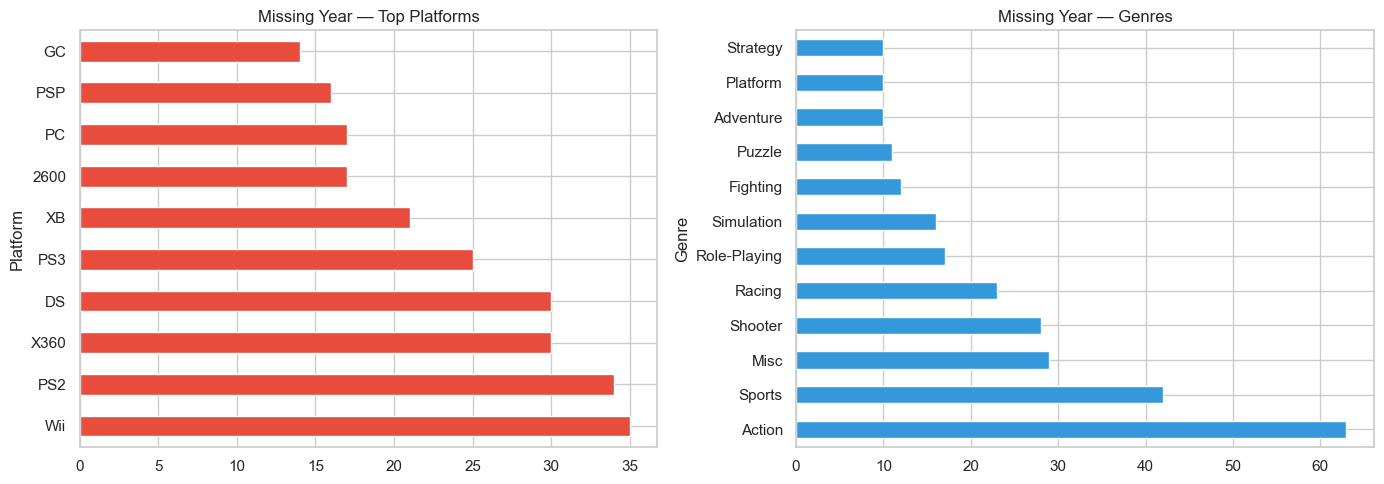

💡 Missing years are spread across platforms and genres — no strong systematic bias.
   Since they represent only ~1.6% of data, dropping them is safe.


In [4]:
# Are the missing-Year games concentrated in certain platforms or publishers?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Year'].isnull()]['Platform'].value_counts().head(10).plot(
    kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Missing Year — Top Platforms')

df[df['Year'].isnull()]['Genre'].value_counts().plot(
    kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Missing Year — Genres')

plt.tight_layout()
plt.show()

print('💡 Missing years are spread across platforms and genres — no strong systematic bias.')
print('   Since they represent only ~1.6% of data, dropping them is safe.')

### 2.1 Handle Missing Year Values

**Decision**: Drop rows where `Year` is missing.

**Why?**
- Only ~1.6% of rows are affected — minimal data loss
- The missing values are spread randomly, not concentrated in specific groups
- Year is critical for time-based analysis — imputing it could introduce bias
- Imputing with median/mode would create artificial data points

In [5]:
# Drop rows with missing Year
rows_before = len(df)
df = df.dropna(subset=['Year'])
rows_after = len(df)

print(f'Rows before: {rows_before:,}')
print(f'Rows after:  {rows_after:,}')
print(f'Rows dropped: {rows_before - rows_after:,} ({(rows_before - rows_after)/rows_before*100:.1f}%)')

Rows before: 16,598
Rows after:  16,327
Rows dropped: 271 (1.6%)


### 2.2 Handle Missing Publisher Values

**Decision**: Replace missing Publisher with `'Unknown'`.

**Why?**
- Only ~58 rows (~0.35%) are affected
- We don't want to lose these rows entirely — they have valid sales data
- Labeling them as 'Unknown' is honest and doesn't introduce false information

In [6]:
# Fill missing Publisher with 'Unknown'
print(f'Missing publishers before: {df["Publisher"].isnull().sum()}')
df['Publisher'] = df['Publisher'].fillna('Unknown')
print(f'Missing publishers after:  {df["Publisher"].isnull().sum()}')

Missing publishers before: 36
Missing publishers after:  0


## 3. Fix Data Types

> **Why fix data types?**  
> `Year` is currently `float64` (e.g., 2006.0). After removing NaN rows, we can safely convert it to `int`. This makes grouping by year cleaner and avoids awkward decimal years in charts.

In [7]:
# Convert Year to integer
df['Year'] = df['Year'].astype(int)

print('Data types after conversion:\n')
print(df.dtypes)
print(f'\nYear range: {df["Year"].min()} to {df["Year"].max()}')

Data types after conversion:

Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Year range: 1980 to 2020


## 4. Check for Duplicates

> **Why check for duplicates?**  
> Duplicate rows would inflate our counts and sales totals. Note that the *same game can appear multiple times* if it was released on different platforms — that's **not** a duplicate, it's a separate release.

In [8]:
# Check for exact duplicate rows
exact_dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {exact_dupes}')

# Check for duplicates based on Name + Platform (same game on same platform)
name_platform_dupes = df.duplicated(subset=['Name', 'Platform']).sum()
print(f'Duplicate Name+Platform combinations: {name_platform_dupes}')

if name_platform_dupes > 0:
    print(f'\nExamples of Name+Platform duplicates:')
    dupe_mask = df.duplicated(subset=['Name', 'Platform'], keep=False)
    print(df[dupe_mask].sort_values(['Name', 'Platform']).head(10))

Exact duplicate rows: 0
Duplicate Name+Platform combinations: 3

Examples of Name+Platform duplicates:
        Rank                         Name Platform  Year   Genre  \
603      604                Madden NFL 13      PS3  2012  Sports   
16127  16130                Madden NFL 13      PS3  2012  Sports   
5900    5902  Need for Speed: Most Wanted       PC  2005  Racing   
11676  11678  Need for Speed: Most Wanted       PC  2012  Racing   
1173    1175  Need for Speed: Most Wanted     X360  2012  Racing   
1530    1532  Need for Speed: Most Wanted     X360  2005  Racing   

             Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
603    Electronic Arts      2.11      0.23      0.00         0.22   
16127  Electronic Arts      0.00      0.01      0.00         0.00   
5900   Electronic Arts      0.02      0.23      0.00         0.05   
11676  Electronic Arts      0.00      0.06      0.00         0.02   
1173   Electronic Arts      0.62      0.80      0.01         0.15   
1530  

In [9]:
# Remove exact duplicates if any exist
if exact_dupes > 0:
    df = df.drop_duplicates()
    print(f'Removed {exact_dupes} exact duplicate rows.')
else:
    print('No exact duplicates found — data is clean in this regard. ✅')

# Note: Name+Platform duplicates may exist because the same game was
# re-released or has different regional entries. We keep them as-is.

No exact duplicates found — data is clean in this regard. ✅


## 5. Validate Column Values

Let's do a final sanity check to ensure all values make sense.

In [16]:
# Check for negative sales (shouldn't exist)
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
for col in sales_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f'{col} has {neg_count} negative values!')
    else:
        print(f'{col} — no negative values')

NA_Sales — no negative values
EU_Sales — no negative values
JP_Sales — no negative values
Other_Sales — no negative values
Global_Sales — no negative values


In [11]:
# Check if Global_Sales ≈ sum of regional sales
df['Calculated_Global'] = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum(axis=1)
df['Sales_Diff'] = abs(df['Global_Sales'] - df['Calculated_Global'])

large_diff = df[df['Sales_Diff'] > 0.1]
print(f'Rows where Global_Sales differs from sum of regional sales: {len(large_diff)}')

if len(large_diff) > 0:
    print('\nExamples:')
    print(large_diff[['Name', 'Global_Sales', 'Calculated_Global', 'Sales_Diff']].head())

# Clean up temporary columns
df = df.drop(columns=['Calculated_Global', 'Sales_Diff'])

Rows where Global_Sales differs from sum of regional sales: 0


In [12]:
# Check Year range makes sense
print(f'Year range: {df["Year"].min()} – {df["Year"].max()}')

# Check for any remaining missing values
print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

Year range: 1980 – 2020

Remaining missing values: 0


## 6. Final Cleaned Dataset Overview

In [13]:
print('=== Cleaned Dataset Summary ===')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'Year range: {df["Year"].min()} – {df["Year"].max()}')
print(f'Platforms: {df["Platform"].nunique()}')
print(f'Genres: {df["Genre"].nunique()}')
print(f'Publishers: {df["Publisher"].nunique()}')
print()
df.info()

=== Cleaned Dataset Summary ===
Shape: 16,327 rows × 11 columns
Missing values: 0
Duplicates: 0
Year range: 1980 – 2020
Platforms: 31
Genres: 12
Publishers: 576

<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  object 
 5   Publisher     16327 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


In [14]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 7. Save Cleaned Dataset

We save the cleaned data to `Data/processed/cleaned_vgsales.csv` so that all subsequent notebooks work with clean data.

In [15]:
# Save to processed folder
df.to_csv('../Data/processed/cleaned_vgsales.csv', index=False)
print('✅ Cleaned dataset saved to: Data/processed/cleaned_vgsales.csv')
print(f'   Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Cleaned dataset saved to: Data/processed/cleaned_vgsales.csv
   Final shape: 16,327 rows × 11 columns


## Summary of Cleaning Steps

| Step | Action | Rows Affected |
|---|---|---|
| Missing Year | Dropped rows | ~271 rows |
| Missing Publisher | Filled with 'Unknown' | ~58 rows |
| Data Types | Year: float → int | All rows |
| Duplicates | Checked — none found | 0 rows |
| Validation | No negative sales, consistent totals | — |

### Next Steps
In **Notebook 03**, we'll create new features (Feature Engineering) to enable deeper analysis.